In [18]:
import pandas as pd # Практическое занятие и освоение визуализации

# Выгрузка данных (891 пассажир Титаника)
df = pd.read_csv('titanic.csv') # Сам файлик сохранён в папке pandas, скачен через cmd Отрывает файлик -> считывает его в таблифу df -> сохраняет df

print("=== Первые пассажиры ===")
print(df.head()) # Считывает название столбцов. По умолчанию всегда 5, но можно увеличить количество df.head(20), анотним df.tail(20) последние

print("\n=== ИНФО О ДАННЫХ ===")
print(df.info()) # Считывает и показывает структуру, количество колонок, строк, их тип данных, а также пропущенные значения (null)

print("\n=== СКОЛЬКО ВЫЖИЛО? ===")
print(f"Выжило: {df['Survived'].sum()} из {len(df)} ({df['Survived'].mean():.1%})")
# Сложная формула на первый взгляд, но пишется почти как на питоне/javascript (был опыт в институте)
# 1. Что такое f"текст"? Форматирование/Умный текст, если бы я выводил через print, то выводился бы буквально текст. Первый опыт применения
# 2. Делаем количество выживших из Выживших. df['Survived'].sum() - суммирует значения среди выживших(342) по колонке 'Survived' (0+1+1+1+0)
# 3. Откуда мы берём общие данные? Старый добрый len(df) или как СOUNT(*) в SQL/JavaScript .lenght(длина). Он считает ВСЕ строки с df
# 4. Теперь подучим старое - df['Survived'].mean() - среднее арифметическое, тот же AVG(SQL). Суммирует (0+1+1+1)(342)/ кол-во строк(841)
# 5. Данные которые мы нашли(0.383938) делаем в презентабельный вид, а именно форматируем(:),умножаем часть на 100(%) и 1 знак после запятой(1) 

=== Первые пассажиры ===
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8

In [35]:
# 1. Выживание по классам
print("Выживание по классам:") 
result = df.groupby('Pclass')['Survived'].mean()
print(f"Класс 1: {result[1]:.1%}")
print(f"Класс 2: {result[2]:.1%}") 
print(f"Класс 3: {result[3]:.1%}")
# Выводим из df классы, делим их на группы (1,2,3) 
# Берём колонку выживших и берём оттуда среднее арифметическое (процент выживших)
# Для красивого вывода делаем форматирование, иначе можно вывести просто print(result) но будет не так красиво

Выживание по классам:
Класс 1: 63.0%
Класс 2: 47.3%
Класс 3: 24.2%


In [38]:
# 2. По полу
print("Выживание по полу:")
result = (df.groupby('Sex')['Survived'].mean())
print(f"Женщины: {result['female']:.1%}")
print(f"Мужчины: {result['male']:.1%}")

Выживание по полу:
Женщины: 74.2%
Мужчины: 18.9%


In [50]:
# 3. Сохранение отчёта
survival_stats = df.groupby(['Sex', 'Pclass'])['Survived'].mean() 
survival_stats.to_excel('titanic_survival.xlsx') 
print("Titanic отчёт готов!") # Привык так делать в институте для проверки работает ли 
# 1. df.groupby(['Sex', 'Pclass']) взаимодействие данного кода работает так: Мы группируем пол и класс по каждому. 3 класс(Жен) и 3(Муж) всего
# 2. Из каждой группы мы высчитываем процент выживших в КАЖДОЙ группе
# 3. Делаем простенький отчётик в excel

Titanic отчёт готов!


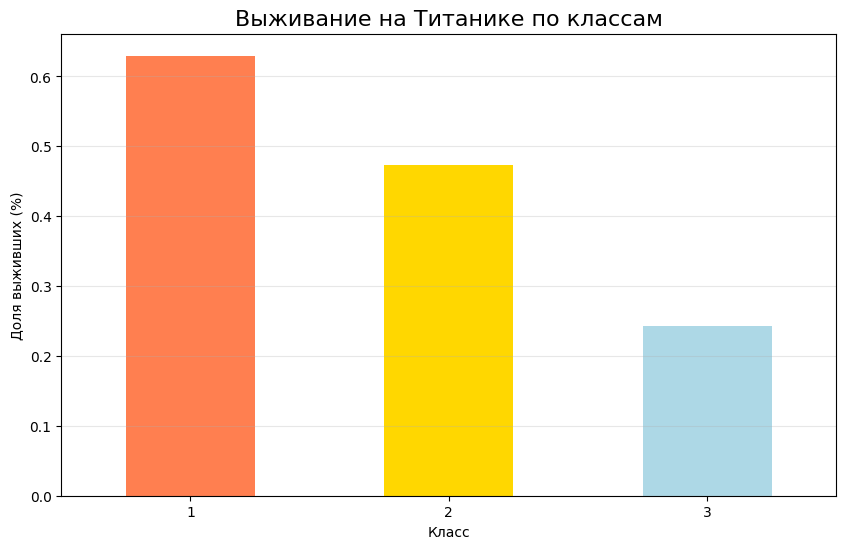

График сохранён: titanic_classes.png
Размер данных: (891, 12)


In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Загружаем Titanic (полный цикл)
df = pd.read_csv('titanic.csv')

# 2. Анализ выживания по классам
survival_by_class = df.groupby('Pclass')['Survived'].mean()

# 3. Создаём график
plt.figure(figsize=(10, 6))
survival_by_class.plot(kind='bar', color=['coral', 'gold', 'lightblue'])
plt.title('Выживание на Титанике по классам', fontsize=16)
plt.ylabel('Доля выживших (%)')
plt.xlabel('Класс')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.savefig('titanic_classes.png', dpi=300, bbox_inches='tight')
plt.show()

print("График сохранён: titanic_classes.png")
print("Размер данных:", df.shape)

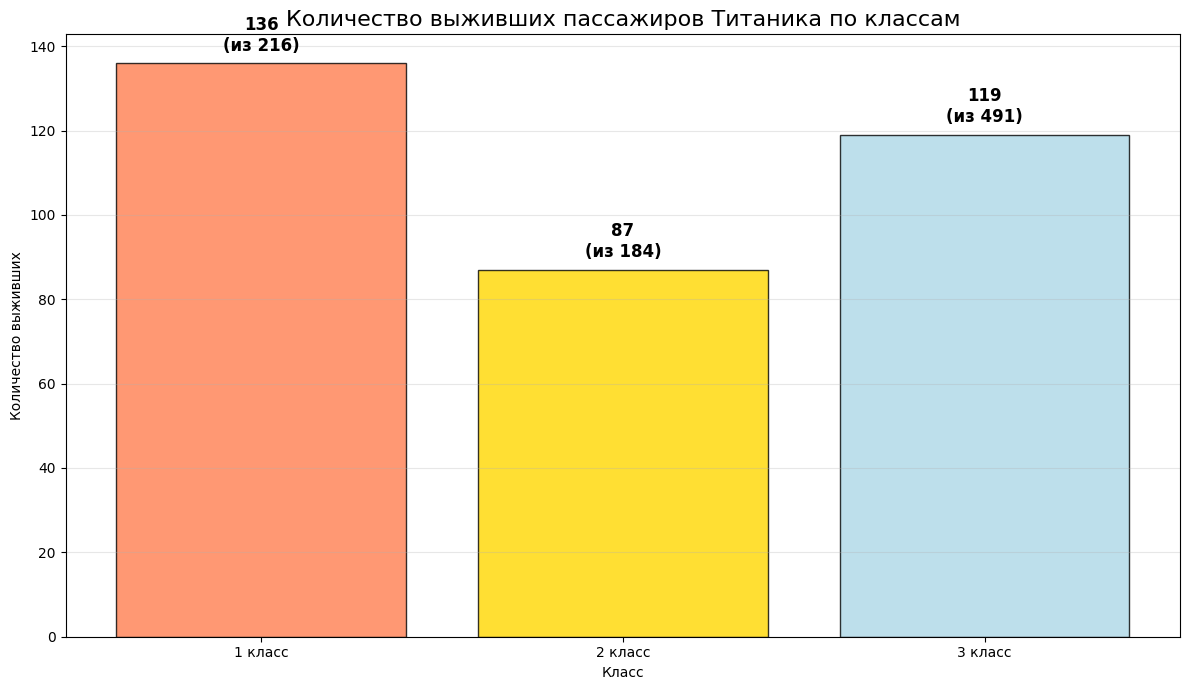

✅ График с числами готов!

Детали:
        survived_count  count
Pclass                       
1                  136    216
2                   87    184
3                  119    491


In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Подсчитываем количество выживших и всех
survival_count = df.groupby('Pclass')['Survived'].agg(['count', 'mean'])
survival_count['survived_count'] = (survival_count['count'] * survival_count['mean']).round(0).astype(int)

# 2. Создаём график
plt.figure(figsize=(12, 7))
bars = plt.bar(range(1, 4), survival_count['survived_count'].values,
               color=['coral', 'gold', 'lightblue'], 
               alpha=0.8, edgecolor='black')

# 3. ДОБАВЛЯЕМ ЧИСЛА НА СТОЛБИКИ
for i, bar in enumerate(bars):
    height = bar.get_height()
    total = survival_count['count'].iloc[i]
    survived = survival_count['survived_count'].iloc[i]
    
    plt.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{survived}\n(из {total})',  # 217 из 345
             ha='center', va='bottom', 
             fontsize=12, fontweight='bold')

plt.title('Количество выживших пассажиров Титаника по классам', fontsize=16)
plt.ylabel('Количество выживших')
plt.xlabel('Класс')
plt.xticks(range(1, 4), ['1 класс', '2 класс', '3 класс'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('titanic_numbers.png', dpi=300)
plt.show()

print("✅ График с числами готов!")
print("\nДетали:")
print(survival_count[['survived_count', 'count']])


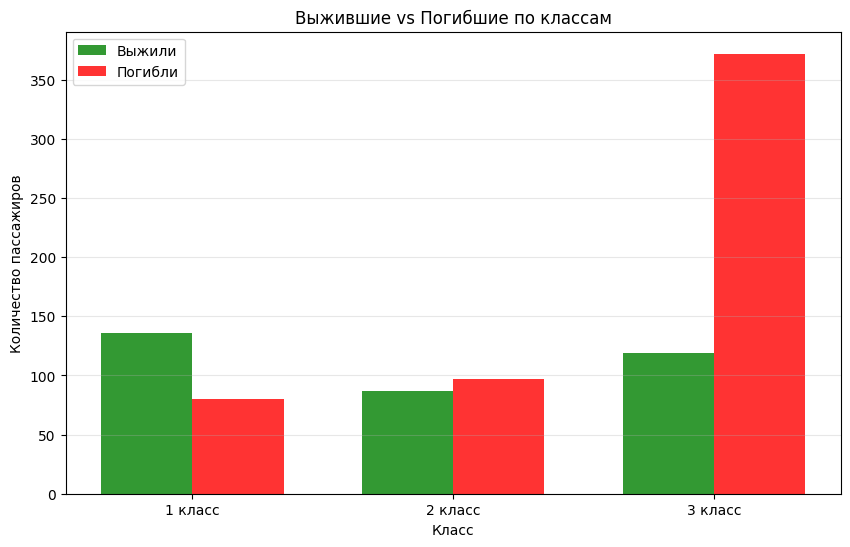

In [14]:
# Выжившие + Погибшие бок о бок
survived = df[df['Survived'] == 1].groupby('Pclass').size()
died = df[df['Survived'] == 0].groupby('Pclass').size()

x = range(1, 4)
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - width/2 for i in x], survived.values, width, label='Выжили', color='green', alpha=0.8)
plt.bar([i + width/2 for i in x], died.values, width, label='Погибли', color='red', alpha=0.8)

plt.title('Выжившие vs Погибшие по классам')
plt.ylabel('Количество пассажиров')
plt.xlabel('Класс')
plt.xticks(x, ['1 класс', '2 класс', '3 класс'])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('titanic_survived_died.png', dpi=300)
plt.show()